# Pastrimi i te Dhenave - AI Dependency & Career Anxiety Among Students

Dataset me 15,000 studente dhe 30 kolona. Qellimi eshte ta pastrojme dhe ta bejme gati per analize.

Hapat qe do ndjekim:
1. Ngarkimi i datasetit
2. Standardizimi i emrave te kolonave
3. Rregullimi i tipeve
4. Trajtimi i vlerave null
5. Heqja e duplikatave
6. Kontrolli i outlier-ave
7. Pastrimi i teksteve
8. Mapimi i vlerave te koduara

## Importet, path-et, leximi i CSV-se dhe ngjyrat

Ky setup ekzekutohet vetem nje here ne fillim. Te gjitha analizat me poshte perdorin te njejtat importe, dataset dhe paleta.


In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


RAW_PATH   = '../data/raw/ai_dependency_career_anxiety_students.csv'
CLEAN_PATH = '../data/clean/ai_students_clean.csv'

Path('../graphs').mkdir(exist_ok=True)

raw_df = pd.read_csv(RAW_PATH)
df = pd.read_csv(CLEAN_PATH)

NAVY = "#333399"
RED = "#C0504D"
GREEN = "#9BBB59"
PURPLE = "#8064A2"
TEAL = "#4BACC6"
ORANGE = "#F79646"
BLUE_MID = "#4F81BD"
WHITE = "#FFFFFF"
DARK_TEXT = "#1F497D"
BG = "#F2F2F2"
PLOT_BG = "#EBEBEB"
GRID = "#D9D9D9"
LINE_COLOR = "#DDDDDD"

PALETTE_6 = [NAVY, RED, GREEN, PURPLE, TEAL, ORANGE]



## 1. Ngarkimi i datasetit

Para cdo gjeje duhet te shohim si duket dataseti. Sa rreshta, cfare kolonash dhe cfare tipesh ka.

In [2]:
def load_dataset():

  dataset = raw_df.copy()
  print(f'Kemi ngarkuar {len(dataset)} rreshta dhe {dataset.shape[1]} kolona.')
  print(dataset.dtypes)
  return dataset


## 2. Standardizimi i emrave te kolonave

Emrat e kolonave duhet te jene te te njejtit format. Lowercase dhe me _ ne vend te hapsirave. Kjo teknike eshte useful sepse python eshte case sensitive, gjithashtu ne rast se duam te bejme lidhje me databazen, do na duhej qe te perdornim kllapa () per kolonat qe kane hapsira.

In [3]:
def column_standardization(df):
  df = df.copy()
  raw_columns = df.columns.tolist()
  df.columns = (df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True))

  columns_changed = [(old_column, new_column) for old_column, new_column  in zip (raw_columns, df.columns) if old_column != new_column]

  if columns_changed:
    print(f"U rregulluan {len(columns_changed)} kolona")
  return df

## 3. Rregullimi i tipeve te te dhenave

Kolonat te cilat marrin vetem disa vlera te caktuara si psh gjinia ose dega i kthejme ne `category` - kjo gje kursen memorie dhe e ben funksionin `groupby()` me te shpejte. `convert_dtypes()` ne fund i ben kolonat e tjera te marrin vlera nullable si psh (Int64).

In [4]:
def optimization_fix_type(df):
  df = df.copy()
  categorical_columns = ['gender', 'degree_type', 'stream', 'college_tier',
                         'urban_or_rural', 'primary_ai_tools_used', 'uses_ai_for_assignments']
  #arsyeja pse e bejme kete eshte qe ne dataset kto te dhena mos te ruhen si string, por si kategori,
  #menyre eficente qe mos te perdorim shume memorie kur kemi vetem disa mundesi kategorish per nje kolone
  for column in categorical_columns:
    df[column] = df[column].astype('category')

  if 'seeks_career_counseling' in df.columns:
    df['seeks_career_counseling'] = df['seeks_career_counseling'].astype('boolean')

  df = df.convert_dtypes() #ben qe kolonat te cilat nuk marin dot vleren null, ta marin ate
  
  return df

## 4. Trajtimi i vlerave null

Kemi shqyrtuar menyren e plotesimit te vlerave null:
- `primary_ai_tools_used` ne kete kolone, mbi 20% e te dhenave mungojne,nje numer i madh per tu plotesuar me ndonje menyre statistikore, prandaj e shenojme si `Unknown`
- Kolonat me ore i plotesojme me **median** , sepse nese ka vlera ekstreme mesatarja do ishte jo dhe aq e sakte 
- `seeks_career_counseling` e ploteojme me `False` sepse nga llogarite vetem rreth 28% e studenteve kerkojne kshillim

In [5]:
def null_handling(df):
  df = df.copy()

  row_num = len(df)
  null_values = df.isnull().sum()
  null_columns = null_values[null_values>0]
  print(f"Numri i vlerave null para rregullimi: {df.isnull().sum().sum()}")
  print(f"Kolonat qe kane null:\n{null_columns.index.tolist()}")

  for column, num in null_columns.items():
    percentage = (num/row_num) * 100
    print(f"Kolona: {column}: {num} mungesa [{percentage:.2f}%]")

  if 'primary_ai_tools_used' in df.columns:
    df['primary_ai_tools_used'] = (df['primary_ai_tools_used'].cat.add_categories('Unknown').fillna('Unknown'))
    # per faktin qe e shtuam kolonen primary_ai_tools_used si kategori, duhet te shtojme opsionin
    # Unknown si kategori gjithashtu. Vlerat qe mungojne i shenojme me unknown.
    # per mendimin tim plotesimi i vlerave boshe me unknown eshte menyra me e mire sepse nuk ka ndonje trend,
    # ose diku ku mund te bazohemi per plotesimin e asaj kategorie. Gjithashtu eshte nje numer shum i madh perqindjeje
    # mungese, keshtuqe plotesimi me nje vlere random do kishte shume ndikim.

  hour_columns = ['sleep_hours', 'social_media_hrs_per_day', 'self_learning_hours_per_week']
  for column in hour_columns:
    if column in df.columns:
      median = round(df[column].median(), 2)
      df[column] = df[column].fillna(median) 
      print(f"Kolona [{column}] u plotesua me vleren: {median}")

  #per plotesimin e ketyra kolonave kisha dy metoda ne mendje. njera prej tyre ishte mesatarja dhe tjetra ishte mesorja.
  #pavaresisht se nuk kam llogaritur akoma vlerat outlying (ato qe mund te jene shum larg vlerave normale), mendoj qe ne rast
  # se do kishim dissa vlera te oreve goxha te shperndara, do te ndikonin per keq ne plotesimin e ketyre vlerave null.
  # keshtu qe mendoj qe median eshte menyra me e sakte.

  if 'seeks_career_counseling' in df.columns:
    df['seeks_career_counseling'] = df['seeks_career_counseling'].fillna(False)
  
  # sipas llogarive qe kam bere me poshte vetem 28.16% e studenteve kerkojne career counseling
  # keshtu qe duke marre parasysh qe shumica e studenteve nuk kerkojne, vlera me te cilen do plotesoj
  # vlerat null te kesaj kolone jane 0 (False)
  # po e komentoj rreshtin me poshte qe mos te ngarkoj afishimin e te dhenave.

  # print(f'{(df["seeks_career_counseling"].sum()) / len(df) *100}% e studenteve konsulohen')

  print(f"Numri i vlerave null pas rregullimi: {df.isnull().sum().sum()}")
  return df.convert_dtypes()

## 5. Heqja e duplikatave

Kemi dy raste, rreshta komplet identik dhe `student_id` te duplikuar, sepse çdo student duhet te jete unik ne dataset.

In [6]:
def remove_duplicates(df):
  df = df.copy()
  row_num_before = len(df)

  df = df.drop_duplicates(keep= 'first')

  if 'student_id' in df.columns:
    df = df.drop_duplicates(subset = 'student_id', keep = 'first')
    # kontrollojme edhe nese id e nje studenti perseritet dy here qe ta fshijme dhe ate rast

  duplicates_dropped = row_num_before - len(df)
  if duplicates_dropped:
    print(f"Numri i duplikatave te fshira: {duplicates_dropped}")
  else:
    print("Dataseti nuk ka duplikata")
    
  return df

## 6. Kontrolli i outlier-ave (IQR + clip)

Perdorim metoden IQR per te gjetur vlerat qe jane shume larg normales. Ne vend te heqjes se rreshtit - gje qe do te humbiste te dhena te tjera te vlefshme te atij studenti, i **kufizojme** vlerat me `clip()` brenda kufijve te llogaritur.

```
Q1 = percentila 25%
Q3 = percentila 75%
IQR = Q3 - Q1
kufiri_poshte = Q1 - 1.5 * IQR
kufiri_lart   = Q3 + 1.5 * IQR
```

In [7]:
def outliers_check(df):
  df = df.copy()

  columns = [
          'daily_ai_tool_usage_hrs',
          'self_learning_hours_per_week',
          'daily_study_hours',
          'social_media_hrs_per_day',
          'sleep_hours',
          'weekly_job_application_count',
      ]
  
  for column in columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3-q1
    qLow = q1 - 1.5 * iqr
    qHigh = q3 + 1.5 * iqr

    outliers_count = ((df[column] < qLow)| (df[column] > qHigh)).sum()
    if outliers_count > 0:
      df[column] = df[column].astype(float).clip(lower = qLow, upper = qHigh)
      print(f"{outliers_count} vlera outliers u kufizuan ne kolonen: {column}")
    else:
      print(f" Kolona [{column}] nuk kishte outliers")
  
  return df

## 7. Standardizimi i teksteve

Problemi tipik: `'male'`, `'Male'`, `' male '` - te treja duhet te trajtohen si e njejta vlere. `str.title()` e zgjidh kete automatikisht. Pas saj bejme disa rregullime manuale per emrat qe `title()` i shkruan gabim, si `'ChatGPT'` qe del `'Chatgpt'`.

In [8]:
def text_standardization(df):
  df = df.copy()

  text_columns = [
        'gender', 'degree_type', 'stream', 'college_tier',
        'urban_or_rural', 'uses_ai_for_assignments', 'primary_ai_tools_used'
    ]
  
  for column in text_columns:
    if hasattr(df[column], 'cat'):
      df[column] =df[column].astype(str).str.strip().str.title().astype('category')
      # kthen kolonen nga kategori ne string , heq hapsirat par mbrapa, ben shkronjen e pare kapitale, e kthen perseri ne kategori.
    else:
      df[column] = df[column].str.strip().str.title()
  
  manual_fix = {
      'Chatgpt':        'ChatGPT',
      'Github Copilot': 'GitHub Copilot',
  }
  if 'primary_ai_tools_used' in df.columns:
      df['primary_ai_tools_used'] = (
          df['primary_ai_tools_used']
          .astype(str)
          .replace(manual_fix)
          .astype('category')
      )

  return df

## 8. Mapimi i vlerave te koduara

`seeks_career_counseling` ruan `0` dhe `1` por kuptimi real eshte `No/Yes`. Kolonat i leme numerike ne rast se do te na nevojiteshin per korelacion dhe modele ML me vone.

In [9]:
def column_mapping(df):
  if 'seeks_career_counseling' in df.columns:
        df['seeks_career_counseling'] = (
            df['seeks_career_counseling']
            .astype(str)
            .map({'True': 'Yes', 'False': 'No', '1.0': 'Yes', '0.0': 'No',
                  '1': 'Yes', '0': 'No'})
            .astype('category')
        )
  return df

## 9. Pipeline - i ekzekutojme te gjitha ne radhe

Te gjitha funksionet i bashkojme ne nje te vetem. Dataseti i pastruar ruhet te `data/clean/`.

In [10]:
def clean_dataset():

    df = load_dataset()
    print('--------------------------------------------------------------------------------------')

    df = column_standardization(df)
    print('--------------------------------------------------------------------------------------')

    df = optimization_fix_type(df)
    print('--------------------------------------------------------------------------------------')

    df = null_handling(df)
    print('--------------------------------------------------------------------------------------')

    df = remove_duplicates(df)
    print('--------------------------------------------------------------------------------------')

    df = outliers_check(df)
    print('--------------------------------------------------------------------------------------')

    df = text_standardization(df)
    print('--------------------------------------------------------------------------------------')

    df = column_mapping(df)

    df.to_csv(CLEAN_PATH, index=False)

    print(f"Madhesia perfundimtare e datasetit: {len(df)} || Kolona: {df.shape[1]} || Mungesa totale (NaN): {df.isnull().sum().sum()}")
    print(f"Skedari  perfundimtar u ruajt tek: {CLEAN_PATH}")
    
    return df

# df_final = clean_dataset()

# Analiza 1 - Profili akademik dhe social i studenteve

Ketu po shohim disa te dhena baze per studentet. Kodi eshte lene sa me i thjeshte, qe te kuptohet lehte cfare po behet ne cdo hap.

## Kolonat qe do analizohen

Ketu vendos emrat e kolonave dhe titujt. Ngjyrat merren nga paleta e vendosur ne fillim.


In [11]:
kolonat = ["gender", "year_of_study", "stream", "urban_or_rural"]
titujt = [
    "Shperndarja sipas gjinise",
    "Shperndarja sipas vitit te studimit",
    "Shperndarja sipas deges",
    "Shperndarja Urban/Rural",
]


## 5. Ndertimi i grafikut

Me nje cikel krijohen kater pie charts. Secili tregon shperndarjen e nje kolone te ndryshme.

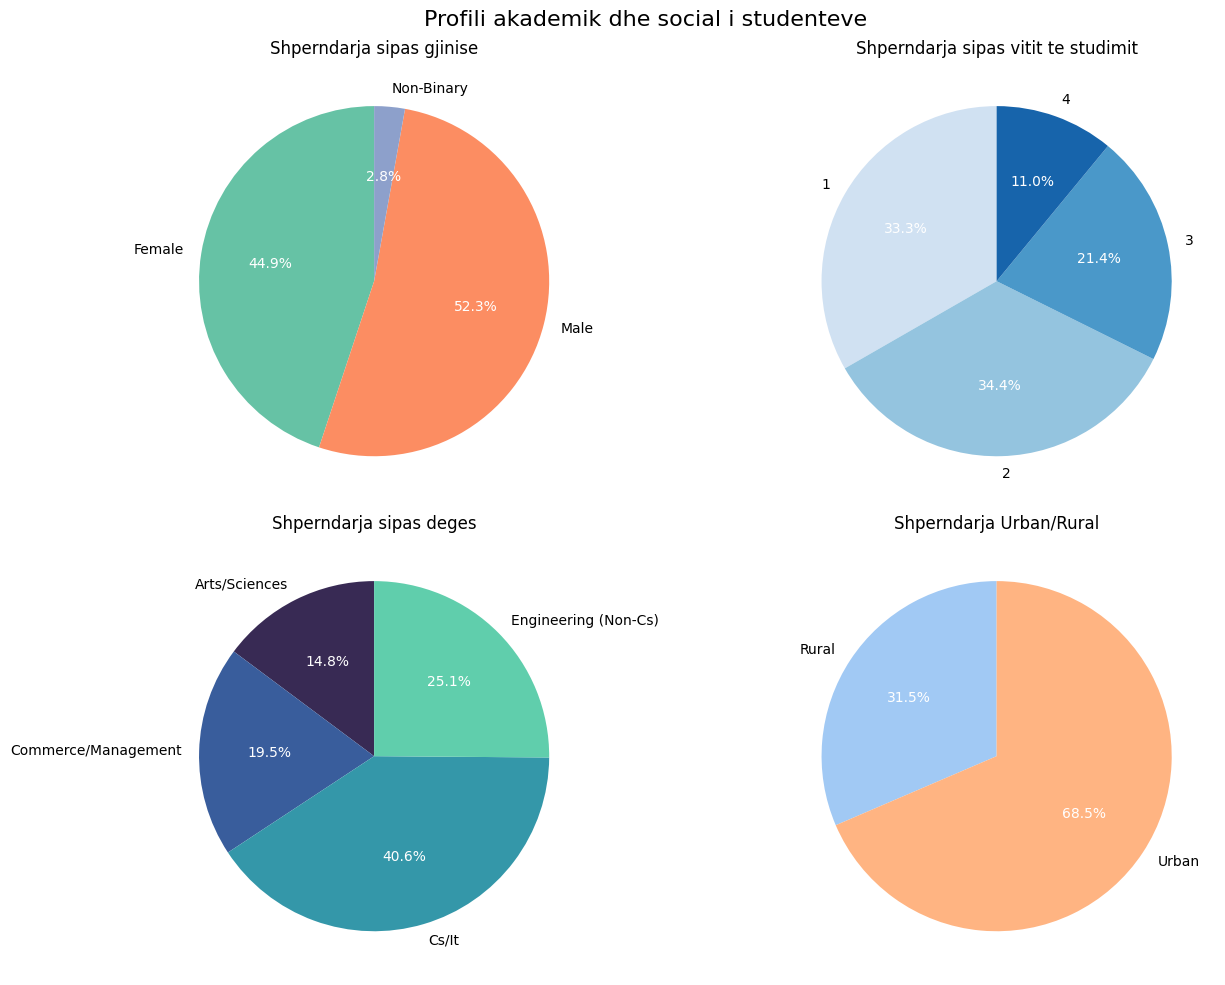

In [12]:
# Krijon nje figure me 4 nen-grafike (2 rreshta dhe 2 kolona)
# figsize percakton madhesine totale te figures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# axes kthehet ne nje array 2D, ndaj e shnderrojme ne 1D
# qe ta aksesojme me lehte me indeks
axes = axes.flatten()

# Loop per secilen kolone qe duam te paraqesim me pie chart
for i in range(len(kolonat)):

    # Numeron sa here shfaqet secila vlere ne kolonen aktuale
    # sort_index() i rendit sipas emrit/vleres se kategorise
    vlera = df[kolonat[i]].value_counts().sort_index()

    # Krijimi i pie chart-it
    wedges, texts, autotexts = axes[i].pie(
        vlera,                         # vlerat numerike te kategorive
        labels=vlera.index,           # emrat e kategorive
        autopct="%1.1f%%",            # shfaq perqindjen me 1 shifer pas presjes
        startangle=90,                # rrotullon grafikun qe te nise nga lart
        colors=sns.color_palette(
            ["Set2", "Blues", "mako", "pastel"][i],  # paleta e ngjyrave per grafikun aktual
            len(vlera)                # numri i ngjyrave sipas kategorive
        ),
    )

    # Vendos perqindjet brenda pie chart-it ne ngjyre te bardhe
    for autotext in autotexts:
        autotext.set_color("white")

    # Vendos titullin per pie chart-in aktual
    axes[i].set_title(titujt[i])

    # Siguron qe pie chart-i te dale perfekt rrethor
    axes[i].set_aspect("equal")

# Titulli kryesor i figures
plt.suptitle(
    "Profili akademik dhe social i studenteve",
    fontsize=16
)

# Rregullon automatikisht hapesirat mes grafikeve
plt.tight_layout()

# Ruajtja e figures ne file PNG
plt.savefig('../graphs/01_01_profili_studenteve_4_piecharts.png')

# Shfaq grafiket ne ekran
plt.show()

# Analiza 2 - Perdorimi i mjeteve AI nga studentet

Ketu po shohim si perdoret AI nga studentet. Kodi eshte mbajtur i thjeshte dhe direkt, pa funksione te vecanta apo file ndihmes.

## 4. Grafiku 1 - Mjetet AI me te perdorura

Ketu numerohen mjetet AI dhe shfaqen me nje bar chart horizontal.

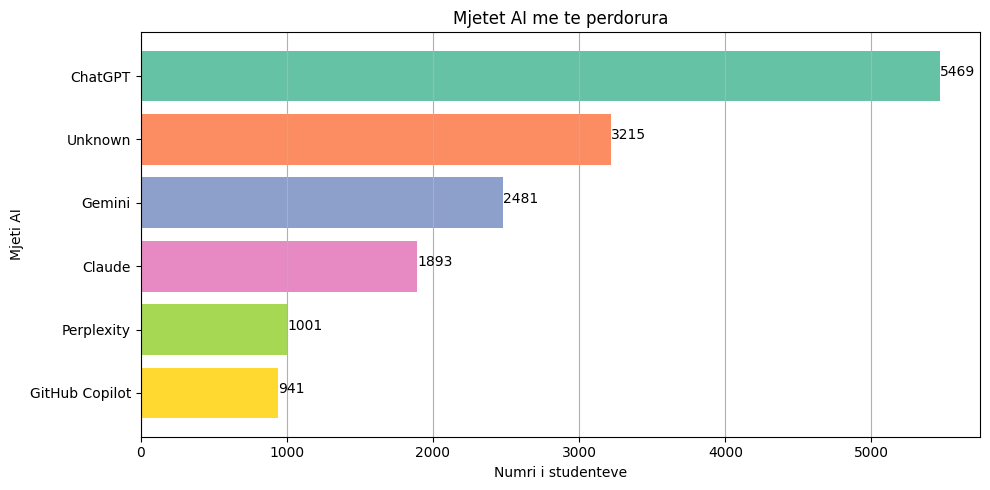

In [13]:
# Numeron sa here eshte perdorur secili mjet AI
tools = df["primary_ai_tools_used"].value_counts()

# Krijon figuren dhe bar chart horizontal
plt.figure(figsize=(10, 5))
plt.barh(
    tools.index,
    tools.values,
    color=sns.color_palette("Set2", len(tools))
)

# Vendos mjetin me te perdorur ne krye
plt.gca().invert_yaxis()

# Shfaq vlerat ne fund te seciles barre
for i, value in enumerate(tools):
    plt.text(value, i, value)

# Titujt dhe etiketat e grafikut
plt.title("Mjetet AI me te perdorura")
plt.xlabel("Numri i studenteve")
plt.ylabel("Mjeti AI")

# Grid vetem ne boshtin horizontal
plt.grid(axis="x")

# Rregullon hapesirat automatike
plt.tight_layout()


plt.savefig("../graphs/01_02_mjetet_ai_me_te_perdorura.png")


plt.show()

## 5. Grafiku 2 - Oret e AI sipas perdorimit per detyra

Ketu krahasohen oret ditore te AI sipas menyres si perdoret AI per detyra.

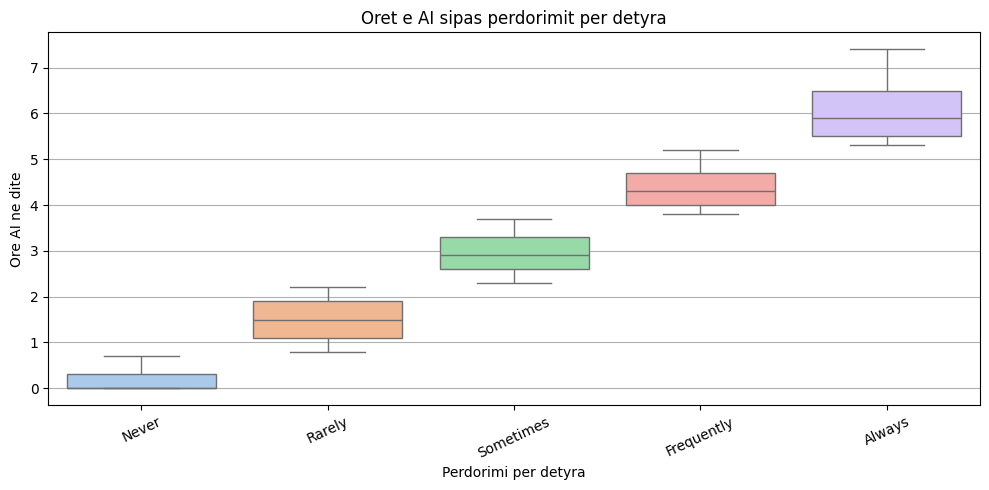

In [14]:
# Merr renditjen e kategorive sipas frekuences se shfaqjes
renditja = df["uses_ai_for_assignments"].value_counts().index

# Krijon figuren
plt.figure(figsize=(10, 5))

# Krijon boxplot per oret e perdorimit te AI
# sipas perdorimit te AI per detyra
sns.boxplot(
    data=df,
    x="uses_ai_for_assignments",
    y="daily_ai_tool_usage_hrs",
    order=renditja,
    palette="pastel",
    hue="uses_ai_for_assignments",
    legend=False,
)

# Vendos titullin dhe etiketat e boshteve
plt.title("Oret e AI sipas perdorimit per detyra")
plt.xlabel("Perdorimi per detyra")
plt.ylabel("Ore AI ne dite")

# Rrotullon tekstin ne boshtin X per lexueshmeri me te mire
plt.xticks(rotation=25)

# Shton grid horizontal
plt.grid(axis="y")

# Rregullon hapesirat automatike
plt.tight_layout()

# Ruan figuren ne folderin e grafikeve
plt.savefig('../graphs/01_03_oret_ai_sipas_detyrave.png')


plt.show()

## 6. Grafiku 3 - Mesatarja sipas deges

Ketu llogaritet mesatarja e oreve te AI per cdo dege dhe shfaqet me bar chart.

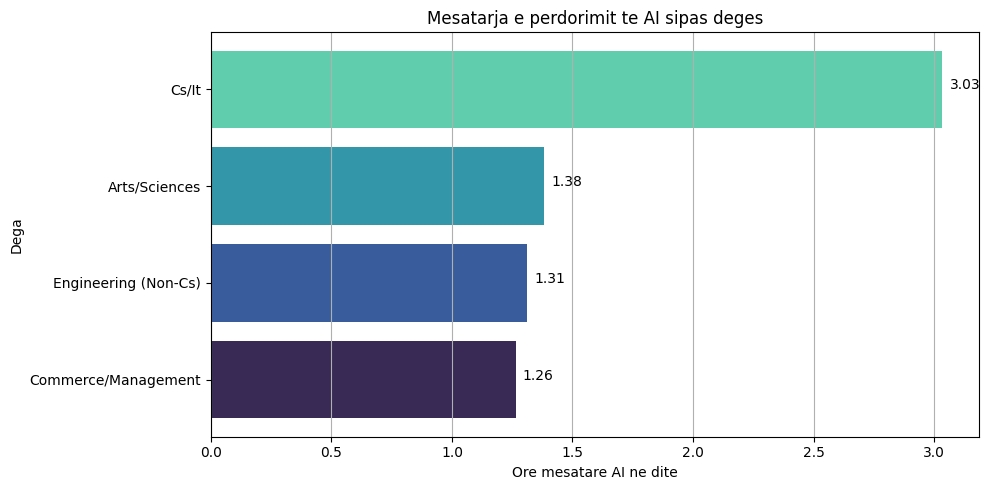

In [15]:
# Llogarit mesataren e oreve te perdorimit te AI per cdo dege
# dhe i rendit nga me e vogla tek me e madhja
deget = (
    df.groupby("stream")["daily_ai_tool_usage_hrs"]
    .mean()
    .sort_values()
)

# Krijon figuren
plt.figure(figsize=(10, 5))

# Krijon grafik horizontal me barre
plt.barh(
    deget.index,
    deget.values,
    color=sns.color_palette("mako", len(deget))
)

# Shfaq vleren mesatare ne fund te seciles barre
for i in range(len(deget)):
    plt.text(
        deget.values[i] + 0.03,
        i,
        f"{deget.values[i]:.2f}"
    )

# Vendos titullin dhe etiketat e boshteve
plt.title("Mesatarja e perdorimit te AI sipas deges")
plt.xlabel("Ore mesatare AI ne dite")
plt.ylabel("Dega")

# Shton grid horizontal
plt.grid(axis="x")

# Rregullon automatikisht hapesirat
plt.tight_layout()

plt.savefig('../graphs/01_04_ai_sipas_deges.png', bbox_inches='tight')

plt.show()

# Analiza 3 - Ndikimi i AI ne pavaresine e te menduarit

Kolonat qe perdorim:
- `ai_replaces_own_thinking_score` - sa i duket studenteve se aftesia e te menduarit
 po zevendesohet nga AI(1-5)
- `ai_dependency_score` - niveli i pergjithshem i varesise (1-10)  
- `daily_ai_tool_usage_hrs` - hours perdorimi ditor
- `uses_ai_for_assignments` - shpeshtesia e perdorimit per detyra

## Pergatitja e kategorive

Dataseti eshte lexuar ne fillim. Ketu i japim nje radhe logjike kategorive te `uses_ai_for_assignments` qe grafiku t'i shfaqe ne rendin e duhur.


In [16]:
df['uses_ai_for_assignments'] = pd.Categorical(
    df['uses_ai_for_assignments'],
    ['Never', 'Rarely', 'Sometimes', 'Frequently', 'Always'],
    ordered=True
)


## Funksioni per stilimin e boshteve

Per te mos e shkruar te njejtin kod 2 here (nje here per cdo grafik), e bej nje funksion qe e merr `ax` dhe i vendos titullin, etiketa dhe ngjyrat.

In [17]:
def setup_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=18, color=DARK_TEXT)
    ax.set_xlabel(xlabel, fontsize=12, color=DARK_TEXT, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, color=DARK_TEXT, labelpad=10)
    ax.set_facecolor(PLOT_BG)

## Grafiku 1 + Grafiku 2 + Ruajtja

Figura, heatmap-i, bubble chart-i dhe ruajtja jane ne te njejten cell — 
qe grafiku mos te dali bosh kur te ekzekutoj kodin.

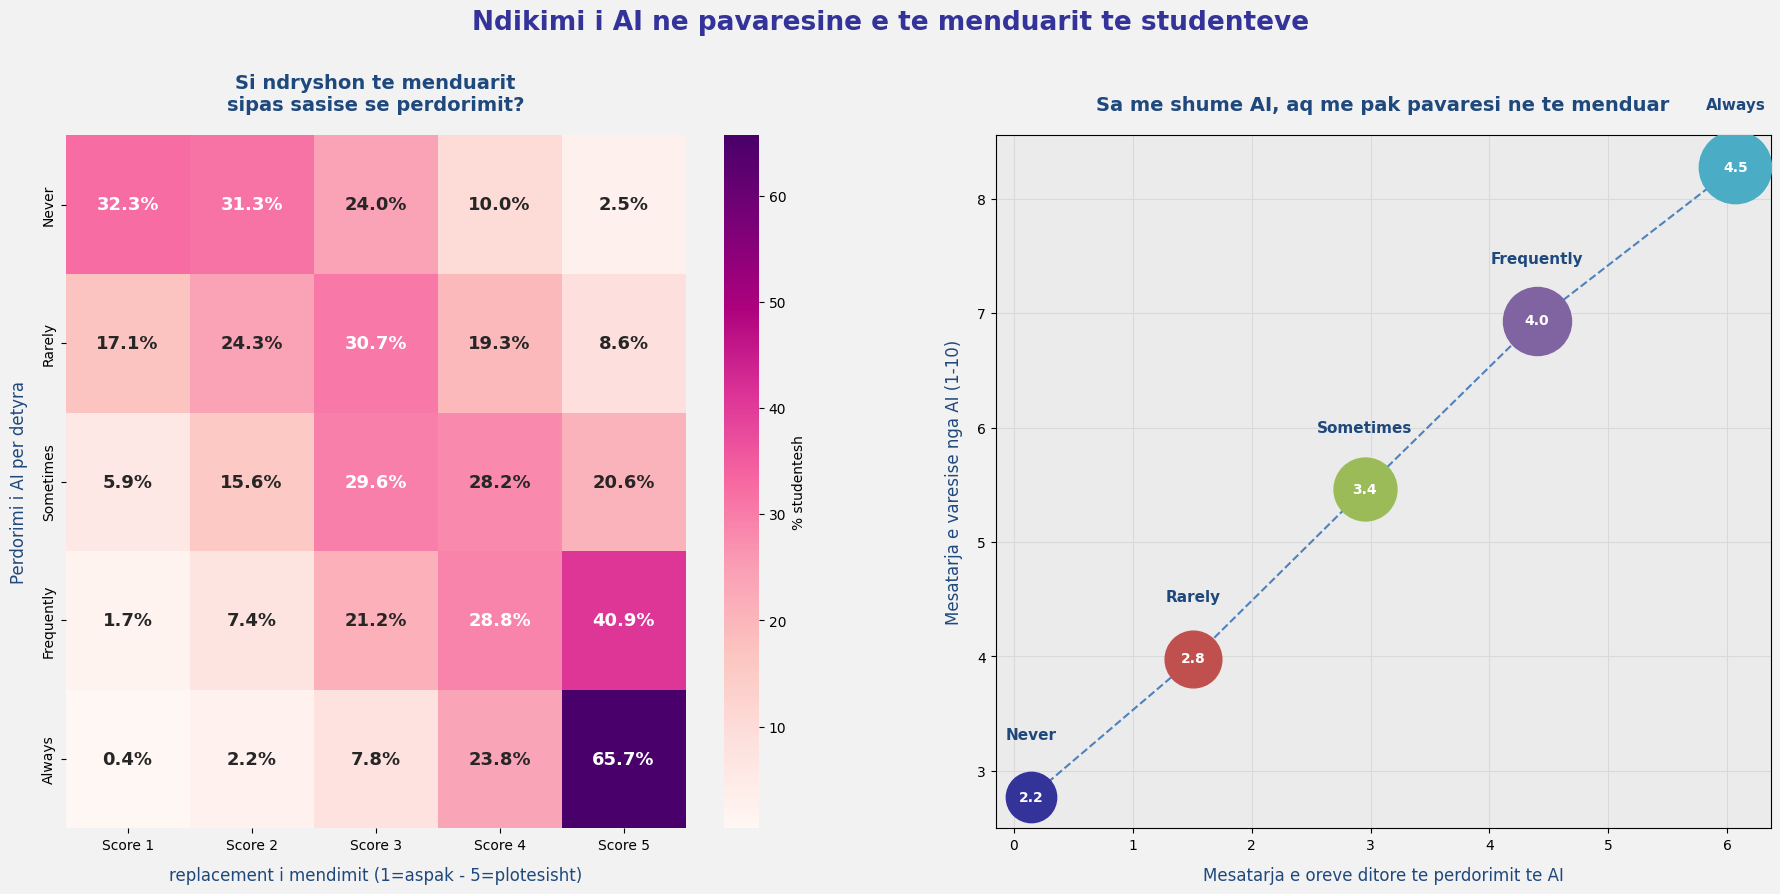

In [18]:
fig, (ax_heat, ax_bubble) = plt.subplots(1, 2, figsize=(22, 9))

fig.patch.set_facecolor(BG)


crossT = (
    pd.crosstab(
        df['uses_ai_for_assignments'],
        df['ai_replaces_own_thinking_score'],
        normalize='index'
    ) * 100
).rename(columns=lambda c: f'Score {c}')

labels = crossT.map(lambda x: f"{x:.1f}%")
sns.heatmap(
    crossT,
    annot=labels,
    fmt='',
    cmap="RdPu", # ngjyrat e heatmapit Red-Purple
    annot_kws={'size': 13,'weight': 'bold'}, # annotation keywords (e kam perdorur per e stilizimin e numrave brenda heatmapit)
    cbar_kws={'label': '% studentesh'},
    ax=ax_heat
)

setup_axis(
    ax_heat,
    'Si ndryshon te menduarit\nsipas sasise se perdorimit?',
    'replacement i mendimit (1=aspak - 5=plotesisht)',
    'Perdorimi i AI per detyra'
)

avg = (
    df.groupby('uses_ai_for_assignments', observed=False)
      .agg(
          hours=('daily_ai_tool_usage_hrs', 'mean'),
          dependency=('ai_dependency_score', 'mean'),
          replacement=('ai_replaces_own_thinking_score', 'mean')
      )
      .reset_index()
)

for hours, dependency, replace, label, color in zip(avg['hours'], avg['dependency'], avg['replacement'],avg['uses_ai_for_assignments'], PALETTE_6[:5]):
    ax_bubble.scatter(hours, dependency, s=replace*600, color=color, zorder=4) #zorder i larte -> tregon qe do shfaqet mbi elementet e tjera me zorder te ulet.
    ax_bubble.text(hours, dependency+0.5, label, ha='center', fontsize=11, fontweight='bold', color=DARK_TEXT)   # +0.5 qe shkrimi (Never ... )mos te behet brenda rrethit
    ax_bubble.text(hours, dependency, f'{replace:.1f}', ha='center', va='center', fontsize=10, fontweight='bold', color=WHITE, zorder=5)

# vija qe lidh bubbles
ax_bubble.plot(avg['hours'], avg['dependency'], color=BLUE_MID, linestyle='--')
ax_bubble.xaxis.grid(True, color=GRID)
ax_bubble.yaxis.grid(True, color=GRID)

setup_axis(ax_bubble,
    'Sa me shume AI, aq me pak pavaresi ne te menduar',
    'Mesatarja e oreve ditore te perdorimit te AI',
    'Mesatarja e varesise nga AI (1-10)')

fig.suptitle(
    'Ndikimi i AI ne pavaresine e te menduarit te studenteve',
    fontsize=19,
    fontweight='bold',
    y=1.02,
    color=NAVY
)

plt.savefig('../graphs/02_01_ai_influence_chart.png')


# Ndikimi i AI dhe ankthi

### Percaktojme kolonat per te cilat do te behet analiza

Dataseti eshte lexuar nje here ne fillim. Ketu testojme nese kolonat qe na duhen jane gati per analize.


In [19]:
metrics = [
    'placement_anxiety_score',
    'fear_of_job_loss_to_ai',
    'career_clarity_score',
    'resume_confidence_score',
    'interview_anxiety_score'
]

df[metrics].describe().round(2).loc[['mean', 'std', 'min', 'max']]
# Test per te pare a jane bere load sakte kolonat


,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,resume_confidence_score,interview_anxiety_score
mean,5.91,3.55,5.03,3.30,6.11
std,2.55,1.18,2.20,1.25,2.64
min,1.00,1.00,1.00,1.00,1.00
max,10.00,5.00,10.00,5.00,10.00


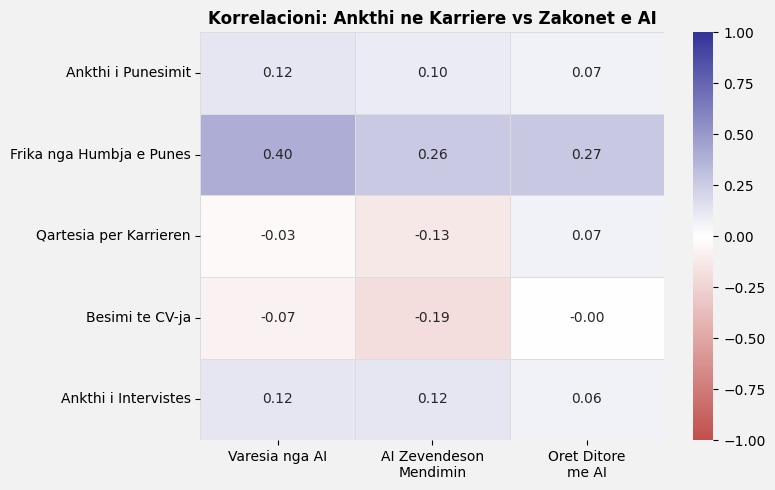

In [20]:
ai_metrics = [
    'ai_dependency_score',
    'ai_replaces_own_thinking_score',
    'daily_ai_tool_usage_hrs'
]

# llogarit matricen e korrelacionit
corr_matrix = df[metrics + ai_metrics].corr()

#marrim ne nje bosh metrics dhe ne boshtin tjeter ai_metrics
subset_corr = corr_matrix.loc[metrics, ai_metrics]

# krijimi i plots dhe vendosja e background colors
fig_corr, ax_corr = plt.subplots(figsize=(8, 5))
fig_corr.set_facecolor(BG)
ax_corr.set_facecolor(PLOT_BG)


# Map per labels ne menyre qe te jete sa me e lexueshme
labels_y = {
    'placement_anxiety_score': 'Ankthi i Punesimit',
    'fear_of_job_loss_to_ai': 'Frika nga Humbja e Punes',
    'career_clarity_score': 'Qartesia per Karrieren',
    'resume_confidence_score': 'Besimi te CV-ja',
    'interview_anxiety_score': 'Ankthi i Intervistes'
}
labels_x = {
    'ai_dependency_score': 'Varesia nga AI',
    'ai_replaces_own_thinking_score': 'AI Zevendeson\nMendimin',
    'daily_ai_tool_usage_hrs': 'Oret Ditore\nme AI'
}

sns.heatmap(
    subset_corr,  #te dhenat qe do te shfaqen
    yticklabels=list(labels_y.values()), # Kalojme labels
    xticklabels=list(labels_x.values()),
    annot=True, #shkruan vlerat brenda cdo kutie 
    cmap=mcolors.LinearSegmentedColormap.from_list("denim_cmap", [RED, WHITE, NAVY]), #ngjyrat custom te heatmap
    fmt=".2f", 
    vmin=-1, # vlerat max dhe min i marrim 1 dhe -1 duke qene se ky eshte intervali i vlerave te korrelacionit
    vmax=1,
    ax=ax_corr, #specifikojme qe do te vizatohet te ax_corr qe te kemi te mundur te stilizojme
    linewidths=0.5,
    linecolor=LINE_COLOR,
)

ax_corr.set_title('Korrelacioni: Ankthi ne Karriere vs Zakonet e AI', fontweight='bold')

plt.tight_layout()
fig_corr.savefig('../graphs/03_01_korrelacioni_ankthi_zakonet_ai.png')
plt.show()


# Pasiguria ne karriere dhe varesia nga AI

### Krijojme kategori per varesine nga AI

Per te bere kete analize do i ndajme studentet ne 3 kategori varesie: e ulet, mesatare dhe e larte

In [21]:
df_analyse = df[metrics + ['ai_dependency_score']].copy()

df_analyse['ai_dependency_level'] = pd.cut(
    df_analyse['ai_dependency_score'],
    bins=3,
    labels=['E Ulet', 'Mesatare', 'E Larte']
)

df_grouped = df_analyse.groupby('ai_dependency_level')[metrics].mean().round(2)
display(df_grouped)

,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,resume_confidence_score,interview_anxiety_score
ai_dependency_level,,,,,
E Ulet,5.69,3.18,5.08,3.38,5.85
Mesatare,6.05,3.82,4.97,3.23,6.28
E Larte,6.48,4.39,4.95,3.17,6.70


### Krijimi i grafikut

Per te paraqitur keto te dhena kemi perdorur bar chart. Duke qene se vlera minimale ne kete grafik eshte 3 e bejme paraqitjen e grafikun nga numri 2 e siper qe diferenca te jete sa me e dukshme.

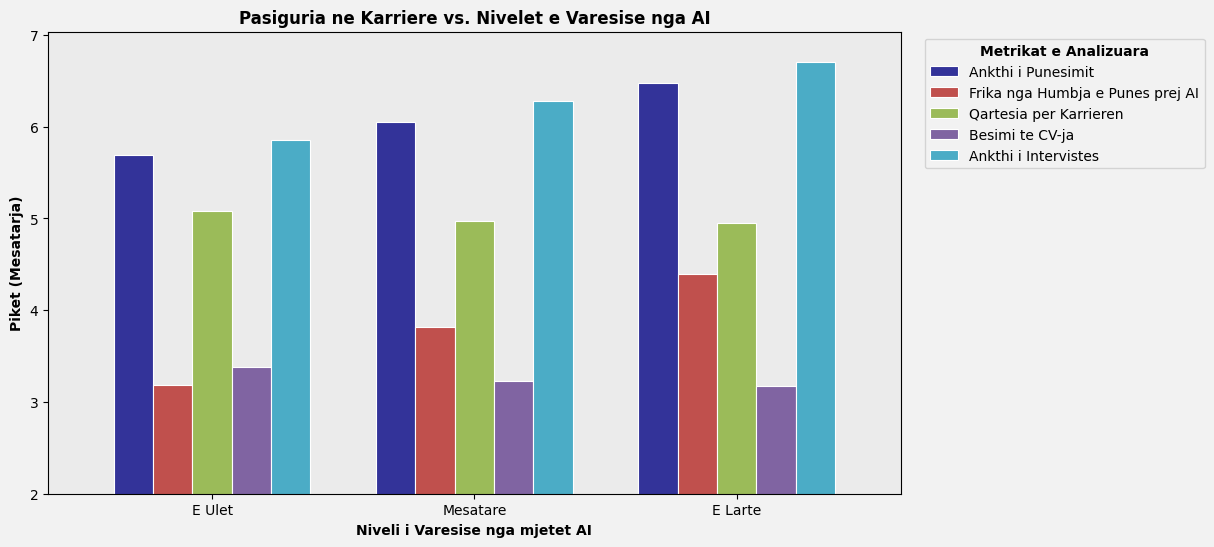

In [22]:
# Map per labels
labels = {
    'placement_anxiety_score': 'Ankthi i Punesimit',
    'fear_of_job_loss_to_ai': 'Frika nga Humbja e Punes prej AI',
    'career_clarity_score': 'Qartesia per Karrieren',
    'resume_confidence_score': 'Besimi te CV-ja',
    'interview_anxiety_score': 'Ankthi i Intervistes'
}

# plot_df eshte dataframe i cili do te kalohet per te krijuar grafikun
plot_df = df_grouped.rename(columns=labels)

# Krijojme plot dhe vendisim bg colors
fig_bar, ax_bar = plt.subplots(figsize=(11, 6))
fig_bar.set_facecolor(BG)
ax_bar.set_facecolor(PLOT_BG)

plot_df.plot(
    kind='bar', #specifikojme qe po krijojme nje bar chart
    ax=ax_bar,
    color=PALETTE_6[:5],
    edgecolor=WHITE,
    linewidth=0.8,
    width=0.75
)

# Vendoosim titullin dhe labels
ax_bar.set_title('Pasiguria ne Karriere vs. Nivelet e Varesise nga AI', fontweight='bold')
ax_bar.set_xlabel('Niveli i Varesise nga mjetet AI', fontweight='bold')
ax_bar.set_ylabel('Piket (Mesatarja)', fontweight='bold')
ax_bar.set_ylim(bottom=2.0)
ax_bar.tick_params(axis='x', rotation=0)
ax_bar.tick_params(axis='y')

legend = ax_bar.legend(
    title='Metrikat e Analizuara',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    facecolor=BG,
)
legend.get_title().set_fontweight('bold')

fig_bar.savefig('../graphs/03_02_ankthi_vs_ai.png')
plt.show()


# Analiza e Profileve te Studenteve AI
This notebook analyzes student engagement profiles based on study hours, self-learning, internship experience, and job applications.

## Pergatitja e te dhenave


### Perpunojme datasetin

Meqenese na duhet numri i oreve te studimit akademik ne jave, e llogarisim dhe e shtojme si kolone te re.


In [23]:
# Marrim numrin e oreve te studimit ne jave
df['study_hours_per_week'] = df['daily_study_hours'] * 5

# Numri i oreve te studimit ne total
df['total_hours_per_week'] = df['study_hours_per_week'] + df['self_learning_hours_per_week']

metric = [
    'internship_experience',
    'weekly_job_application_count',
    'daily_study_hours',
    'self_learning_hours_per_week',
    'skill_development_courses_taken',
    'study_hours_per_week'
]

df.head()


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score,study_hours_per_week,total_hours_per_week
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-Cs),3,Tier 3,Rural,0.3,Perplexity,...,2,1.5,8.5,1,3,6,No,9.09,17.5,26.2
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-Cs),4,Tier 3,Urban,1.9,ChatGPT,...,3,4.2,8.3,4,5,3,No,6.03,12.0,20.2
2,STU_00003,25,Female,Mba,Cs/It,1,Tier 3,Urban,3.6,Gemini,...,1,2.3,7.0,5,9,3,Yes,6.68,11.5,27.9
3,STU_00004,23,Male,B.Tech/B.E.,Cs/It,1,Tier 1,Urban,4.1,GitHub Copilot,...,3,2.6,7.2,6,6,6,No,7.71,38.5,53.5
4,STU_00005,22,Female,Mba,Cs/It,1,Tier 1,Urban,3.4,ChatGPT,...,2,1.9,8.0,3,5,4,No,4.64,12.0,13.1


### Segmentimi i studenteve sipas profilit

Per te zhvilluar analizen do te bejme profilizimit te studenteve. Profilizimi do te kryhet bazuar ne oret totale te te mesuarit duke marr parasysh te mesuarin akademik dhe te mesuarit te pavarur.

In [24]:
def percakto_profilin(ore_totale):
    if ore_totale < 15:
        return 'Profil_A (Pasive)'
    elif ore_totale <= 35:
        return 'Profil_B (Mesatare)'
    else:
        return 'Profil_C (Super-Aktive)'

df['Emri_Profilit'] = df['total_hours_per_week'].apply(percakto_profilin)

# Profile distribution
print(df['Emri_Profilit'].value_counts())

Emri_Profilit
Profil_B (Mesatare)        7481
Profil_A (Pasive)          5659
Profil_C (Super-Aktive)    1860
Name: count, dtype: int64


### Numri i oreve te te mesuarit dhe kerkimi aktiv per punesim

Gjate kesaj analize do te shohim se cili grup studentesh eshte me aktiv ne gjetjen e punesimit

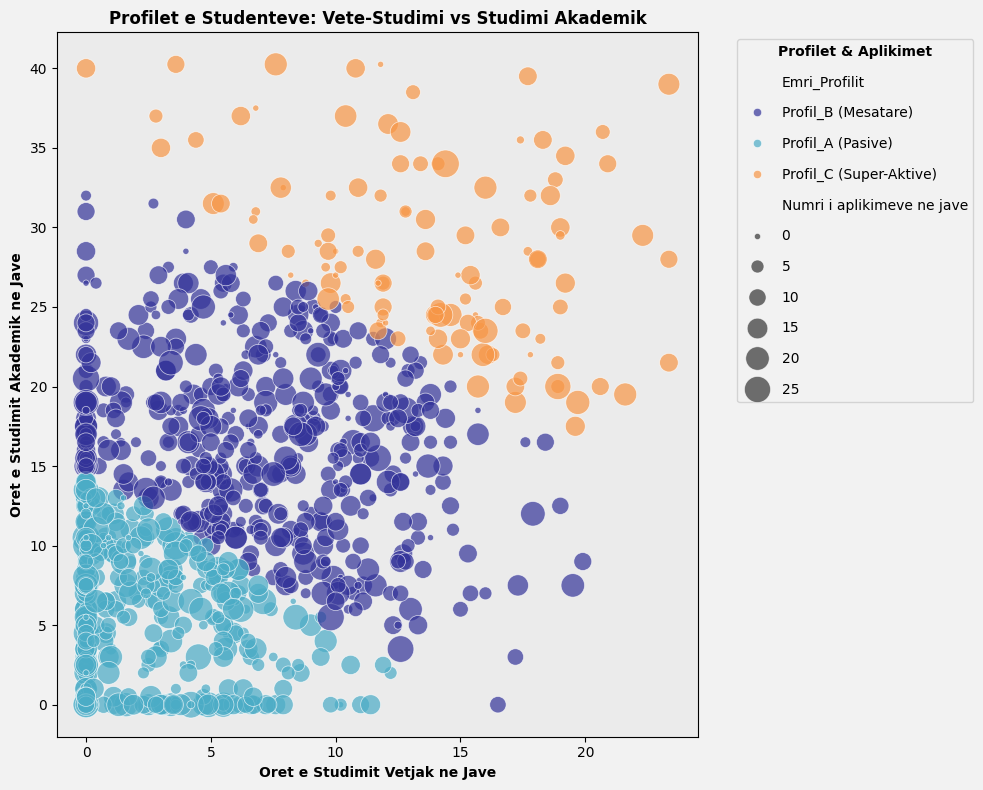

In [25]:
df_sample = df.sample(1000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PLOT_BG)

sns.scatterplot(
    data=df_sample,
    x='self_learning_hours_per_week',
    y='study_hours_per_week',
    hue='Emri_Profilit',
    size='weekly_job_application_count',
    sizes=(20, 400),
    alpha=0.7,
    palette=[NAVY, TEAL, ORANGE],
    ax=ax
)

ax.set_title('Profilet e Studenteve: Vete-Studimi vs Studimi Akademik', fontweight='bold')
ax.set_xlabel('Oret e Studimit Vetjak ne Jave', fontweight='bold')
ax.set_ylabel('Oret e Studimit Akademik ne Jave', fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
# custom label per legjenden
labels = [l.replace('weekly_job_application_count', 'Numri i aplikimeve ne jave') for l in labels]

legend = plt.legend(
    handles, labels,
    bbox_to_anchor=(1.05, 1),
    title='Profilet & Aplikimet',
    facecolor=BG,
    labelspacing=1.2,
)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
fig.savefig('../graphs/03_03_study_hours_job_applications.png')
plt.show()


### Ndjekja e kurseve dhe pergatitja profesionale

Gjate kesaj analize kemi pare se si ndjekja e kurseve ndikon ne pergatitjen e studenteve per pune.

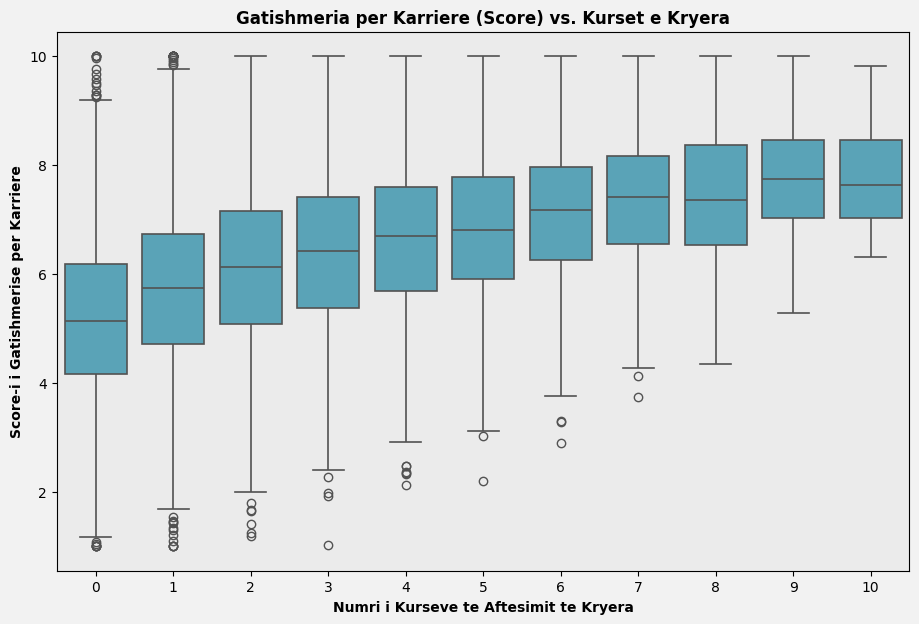

In [26]:
fig1, ax1 = plt.subplots(figsize=(11, 7))
fig1.patch.set_facecolor(BG)
ax1.set_facecolor(PLOT_BG)

sns.boxplot(
    data=df,
    x='skill_development_courses_taken',
    y='overall_career_readiness_score',
    color=TEAL,
    ax=ax1,
    linewidth=1.2,
    showfliers=True
)

ax1.set_title('Gatishmeria per Karriere (Score) vs. Kurset e Kryera', fontweight='bold')
ax1.set_xlabel('Numri i Kurseve te Aftesimit te Kryera', fontweight='bold')
ax1.set_ylabel('Score-i i Gatishmerise per Karriere', fontweight='bold')

fig1.savefig('../graphs/03_04_courses_career_readiness.png')
plt.show()


# Analize kompakte - Mireqenia Personale e Studenteve

Pyetja qe mundohem t'i jap pergjigje: **a lidhen me shume rrjete sociale dhe me pak gjume me presion psikologjik me te larte tek studentet?**

Kolonat qe perdorim:

- `social_media_hrs_per_day` - ore ne rrjete sociale ne dite
- `sleep_hours` - ore gjumi
- `stress_level` - niveli i stresit
- `burnout_score` - niveli i burnout-it
- `motivation_score` - niveli i motivimit

Analiza eshte nje analize e vetme, e ndare ne **2 tabela pershkruese** dhe **2 grafike**.

## Pergatitja e kolonave

Dataseti eshte lexuar ne fillim. Ketu marrim vetem kolonat qe na duhen per kete analize dhe i kthejme ne numerike.


In [27]:
cols = [
    'social_media_hrs_per_day',
    'sleep_hours',
    'stress_level',
    'burnout_score',
    'motivation_score',
]

df = df[cols].apply(pd.to_numeric).copy()

# Indeksi i presionit psikologjik: stres + burnout - motivim.
# Kolonat standardizohen qe te krahasohen ne te njejten shkalle.
z = (df - df.mean()) / df.std(ddof=0)
df['psychological_pressure_index'] = (
    z['stress_level'] +
    z['burnout_score'] -
    z['motivation_score']
) / 3

# Grupet qe do perdoren ne tabelen dhe grafikun e dyte.
df['social_media_group'] = pd.cut(
    df['social_media_hrs_per_day'],
    bins=[-0.01, 2, 4, df['social_media_hrs_per_day'].max() + 0.01],
    labels=['0-2 ore', '2-4 ore', '4+ ore']
)

df['sleep_group'] = pd.cut(
    df['sleep_hours'],
    bins=[df['sleep_hours'].min() - 0.01, 6, 7.5, df['sleep_hours'].max() + 0.01],
    labels=['<6 ore', '6-7.5 ore', '>7.5 ore']
)


## Funksioni ndihmes per stilin e boshteve

Per te mos perseritur te njejtat komanda ne te dy grafiket, perdorim nje funksion te thjeshte qe vendos titullin, etiketat, ngjyrat dhe sfondin e brendshem.

In [28]:
def setup_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, fontweight='bold', color=NAVY)
    ax.set_xlabel(xlabel, color=DARK_TEXT)
    ax.set_ylabel(ylabel, color=DARK_TEXT)
    ax.set_facecolor(PLOT_BG)

## Tabela 1 + Grafiku 1 - Korelacionet kryesore

Kjo pjese tregon lidhjet kryesore midis rrjeteve sociale, gjumit, stresit, burnout-it dhe motivimit.

,lidhja,korelacioni_r
0,Rrjete sociale vs gjume,-0.222
1,Gjume vs stres,-0.322
2,Gjume vs burnout,-0.171
3,Burnout vs motivim,-0.538
4,Rrjete sociale vs motivim,-0.286


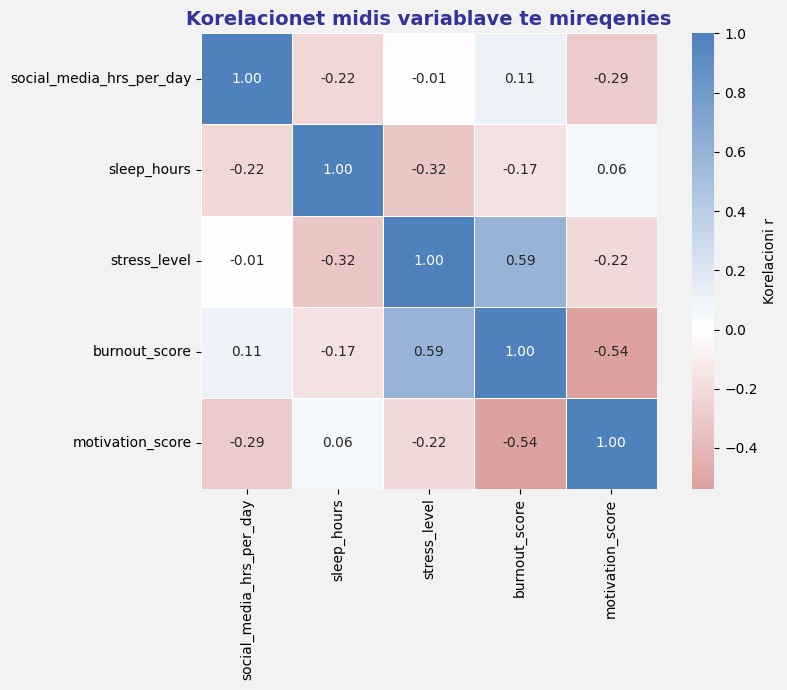

In [29]:
corr = df[cols].corr()

key_relationships = pd.DataFrame({
    'lidhja': [
        'Rrjete sociale vs gjume',
        'Gjume vs stres',
        'Gjume vs burnout',
        'Burnout vs motivim',
        'Rrjete sociale vs motivim',
    ],
    'korelacioni_r': [
        corr.loc['social_media_hrs_per_day', 'sleep_hours'],
        corr.loc['sleep_hours', 'stress_level'],
        corr.loc['sleep_hours', 'burnout_score'],
        corr.loc['burnout_score', 'motivation_score'],
        corr.loc['social_media_hrs_per_day', 'motivation_score'],
    ]
})

key_relationships['korelacioni_r'] = key_relationships['korelacioni_r'].round(3)
display(key_relationships)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PLOT_BG)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=sns.blend_palette([RED, WHITE, BLUE_MID], as_cmap=True),
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'label': 'Korelacioni r'},
    ax=ax
)

setup_axis(
    ax,
    'Korelacionet midis variablave te mireqenies',
    '',
    ''
)

plt.tight_layout()
plt.show()


## Tabela 2 + Grafiku 2 - Presioni psikologjik sipas grupeve

Kjo pjese tregon si ndryshon presioni psikologjik kur kombinojme oret e gjumit me oret ne rrjete sociale.

n  avg_pressure_index
sleep_group social_media_group                          
<6 ore      0-2 ore              474                0.21
            2-4 ore             1108                0.23
            4+ ore              1017                0.38
6-7.5 ore   0-2 ore             2204               -0.10
            2-4 ore             3699                0.02
            4+ ore              2164                0.15
>7.5 ore    0-2 ore             1646               -0.31
            2-4 ore             1913               -0.18
            4+ ore               775               -0.08

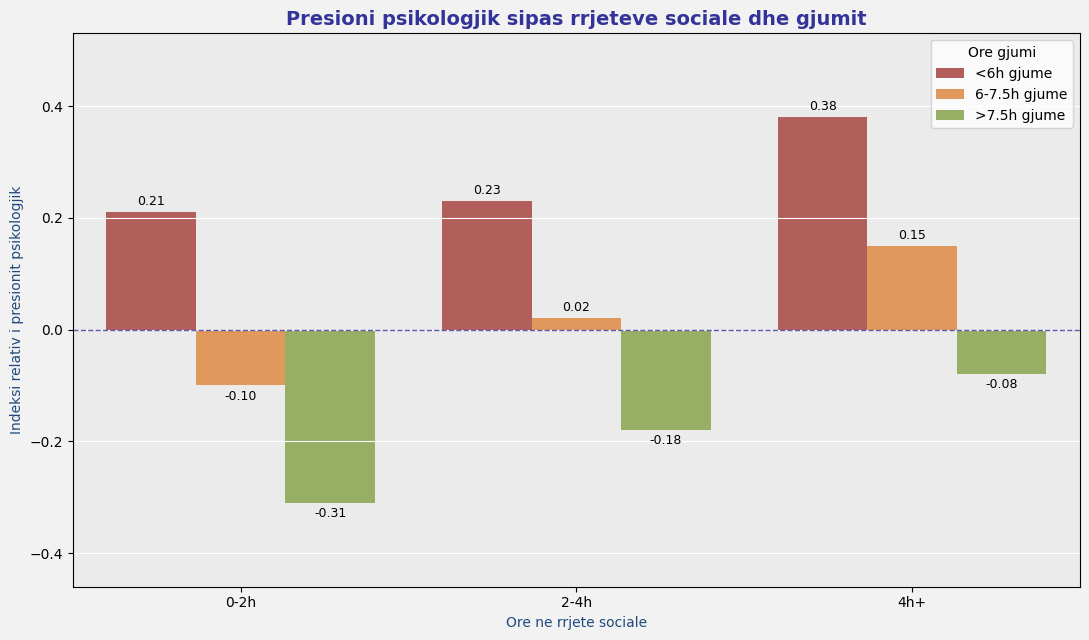

In [30]:
profile = (
    df.groupby(['sleep_group', 'social_media_group'], observed=False)
      .agg(
          n=('psychological_pressure_index', 'size'),
          avg_pressure_index=('psychological_pressure_index', 'mean')
      )
      .round(2)
)

display(profile)

plot_data = profile.reset_index().copy()

social_short = {
    '0-2 ore': '0-2h',
    '2-4 ore': '2-4h',
    '4+ ore': '4h+',
}

sleep_short = {
    '<6 ore': '<6h gjume',
    '6-7.5 ore': '6-7.5h gjume',
    '>7.5 ore': '>7.5h gjume',
}

plot_data['social_media_label'] = plot_data['social_media_group'].astype(str).map(social_short)
plot_data['sleep_label'] = plot_data['sleep_group'].astype(str).map(sleep_short)

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PLOT_BG)

sns.barplot(
    data=plot_data,
    x='social_media_label',
    y='avg_pressure_index',
    hue='sleep_label',
    palette=[RED, ORANGE, GREEN],
    ax=ax
)

ax.axhline(0, color=NAVY, linewidth=1, linestyle='--', alpha=0.8)
setup_axis(
    ax,
    'Presioni psikologjik sipas rrjeteve sociale dhe gjumit',
    'Ore ne rrjete sociale',
    'Indeksi relativ i presionit psikologjik'
)
ax.legend(title='Ore gjumi', frameon=True, facecolor=WHITE)
ax.grid(axis='y', color=WHITE)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

ax.set_ylim(
    plot_data['avg_pressure_index'].min() - 0.15,
    plot_data['avg_pressure_index'].max() + 0.15
)

plt.tight_layout()
plt.show()


## Perfundime

- Grafiku dhe tabela e pare tregojne se rrjetet sociale lidhen negativisht me gjumin dhe motivimin, ndersa burnout-i ka lidhjen me te forte negative me motivimin.
- Grafiku dhe tabela e dyte tregojne se grupi me presionin me te larte eshte ai me `<6 ore` gjume dhe `4+ ore` rrjete sociale.
- Grupi me presionin me te ulet eshte ai me `>7.5 ore` gjume dhe `0-2 ore` rrjete sociale.
- Rezultatet tregojne lidhje statistikore, jo shkak-pasoje.